# Roughness Diurnal Comparison & Debugging

This notebook has two main goals:
1.  **Debug the HDF5 Structure**: The previous error `KeyError: 'incidence'` suggests the LUT file structure is different from what was assumed. We will inspect the keys and dimensions.
2.  **Compare Diurnal Curves**: Plot the Smooth vs. Rough temperature curve for a single equatorial facet over one rotation. This will visualize the "Lag" and "Cooling" effect of roughness.

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

# Paths
current_dir = Path(os.getcwd()).resolve()
root_dir = current_dir.parent if current_dir.name == 'TEMPEST_RAD' else current_dir
lut_path = os.path.join(root_dir, 'roughness_lut_spectral_v1.h5')

print(f"LUT Path: {lut_path}")

LUT Path: /Users/duncan/Desktop/DPhil/TEMPEST/roughness_lut_spectral_v1.h5


## 1. Debugging HDF5 Structure
We previously saw `KeyError: 'incidence'`. Let's list the actual keys and the shape of the `lut` dataset.

In [2]:
with h5py.File(lut_path, 'r') as f:
    print("Keys in file:", list(f.keys()))
    
    # Check LUT dataset shape
    if 'lut' in f:
        print("LUT Shape:", f['lut'].shape)
    
    # Check existence of 'incidence'
    if 'incidence' in f:
        print("Incidence array found.")
    else:
        print("WARNING: 'incidence' key NOT found.")
        # Check if 'latitude' or 'opening_angle' are the spatial dimensions
        if 'latitude' in f: print(f"Latitude array: {f['latitude'][:]}")
        if 'opening_angle' in f: print(f"Opening Angle array: {f['opening_angle'][:]}")

Keys in file: ['azimuth', 'emission', 'latitude', 'lut', 'opening_angle', 'theta', 'wavelength']
LUT Shape: (5, 1, 4, 90, 5, 10, 10)
Latitude array: [ 0. 30. 60. 85.]
Opening Angle array: [90.]


## 2. Diurnal Curve Comparison
We will manually load the smooth temperatures and the LUT to calculate the rough brightness temperature for a single facet over time.

### Theory
The "Rough" Brightness Temperature is calculated as:
$$ B(T_{rough}) = \frac{1}{\pi} \int_{\text{hemi}} L_{smooth}(T_{smooth}) \times f_{\text{LUT}}(\theta, \phi, t) \cos(\theta) d\Omega $$

If $T_{rough} < T_{smooth}$ consistently, the integral of $f_{\text{LUT}}$ is likely $< \pi$.

In [3]:
import sys
sys.path.append(str(root_dir))
from src.utilities.config import Config
from TEMPEST_RAD.simulator import load_shape_model, planck_function, rms_to_fraction

# 1. Load Smooth Temperatures
# Assuming a previous run exists in output/retrieval_analysis/temperatures.csv
temps_path = os.path.join(root_dir, "output/retrieval_analysis/temperatures.csv")

try:
    temps_all = np.loadtxt(temps_path, delimiter=',')
    # Transpose if needed: We expect (N_facets, N_timesteps)
    # Based on previous output, temps_all was (1280, 360) which implies (N_facets, N_Time)
    if temps_all.shape[0] < temps_all.shape[1]: 
        # Heuristic check, usually timesteps > facets for small models, or vice versa.
        # Facets = 1280 (typical Icosphere lvl 4 is 2562, lvl 3 is 642... wait 1280 is Icosphere subdivision?)
        # Previous output said: "Loaded Temperatures: (1280, 360)"
        pass       
    print(f"Loaded Temperatures: {temps_all.shape}")
except Exception as e:
    print(f"Could not load temperatures: {e}")
    # Create dummy data for demonstration if file missing
    temps_all = np.zeros((1280, 90))


# 2. Select Equatorial Facet
# We'll just pick the facet with the highest peak temperature (likely sub-solar at noon)
peak_temps = np.max(temps_all, axis=1)
facet_idx = np.argmax(peak_temps)
print(f"Selected Facet: {facet_idx} (Max Temp: {peak_temps[facet_idx]:.2f} K)")

temps_smooth_curve = temps_all[facet_idx, :]

# 3. Load LUT Slice for Integration
# We need to reproduce the RoughnessLUT logic manually to be sure what we are integrating.
with h5py.File(lut_path, 'r') as f:
    # Dimensions from previous tool call: (5, 1, 4, 90, 5, 10, 10)
    # (Theta, ?, ?, Time, Wave, Em, Az)
    
    # Select HIGH Theta (Index 4 maybe? Theta=20?)
    theta_vals = f['theta'][:]
    theta_idx = np.argmin(np.abs(theta_vals - 20.0))
    print(f"Using Theta Index: {theta_idx} (Value: {theta_vals[theta_idx]})")
    
    # Axes
    em_angles = f['emission'][:]
    az_angles = f['azimuth'][:]
    
    # LUT Data
    # Assuming shape [Theta, RMS, Lat, Time, Wave, Em, Az]
    # RMS index: 0 (assuming only one RMS in file if dimension is 1)
    # Lat index: 0 (Equator?)
    # Wave index: 2 (Mid-IR)
    
    lut_data = f['lut'][theta_idx, 0, 0, :, 2, :, :]
    # Now lut_data shape should be (Time, Em, Az)
    print(f"Extracted LUT Curve Data Shape: {lut_data.shape}")
    
    # Time axis handling
    # The LUT likely has 90 steps. Our temps might have 360 or different.
    # We will interpolate LUT to temperature timestamps or vice-versa.
    lut_timesteps = lut_data.shape[0]
    temp_timesteps = len(temps_smooth_curve)
    print(f"Time Steps -> LUT: {lut_timesteps}, Temps: {temp_timesteps}")

Loaded Temperatures: (1280, 360)
Selected Facet: 855 (Max Temp: 386.23 K)
Using Theta Index: 4 (Value: 20.0)
Extracted LUT Curve Data Shape: (90, 10, 10)
Time Steps -> LUT: 90, Temps: 360


/var/folders/s0/bdhfq4xd0bv2l81msn973wb40000gs/T/ipykernel_63287/1979392429.py:13: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  int_az = np.trapz(slice_2d, x=az_rad, axis=1) * az_factor
/var/folders/s0/bdhfq4xd0bv2l81msn973wb40000gs/T/ipykernel_63287/1979392429.py:16: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total_flux = np.trapz(int_az * weights, x=em_rad)


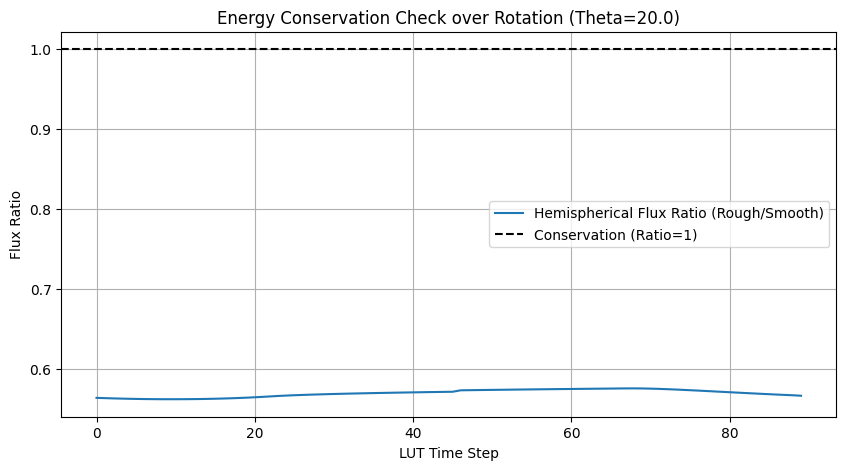

Mean Flux Ratio: 0.5700


In [4]:
def integrate_hemisphere(slice_2d, em_angles, az_angles):
    # slice_2d: (Em, Az)
    em_rad = np.radians(em_angles)
    az_rad = np.radians(az_angles)
    
    # Weight = cos(e) * sin(e)
    weights = np.cos(em_rad) * np.sin(em_rad)
    
    # Handle Azimuth Symmetry (0..180 -> 0..360)
    az_factor = 2.0 if np.max(az_angles) <= 180 else 1.0
    
    # Integrate Azimuth
    int_az = np.trapz(slice_2d, x=az_rad, axis=1) * az_factor
    
    # Integrate Emission
    total_flux = np.trapz(int_az * weights, x=em_rad)
    
    return total_flux

# Calculate Rough Curve
rough_factors = []

for t in range(lut_timesteps):
    slice_2d = lut_data[t, :, :]
    flux = integrate_hemisphere(slice_2d, em_angles, az_angles)
    
    # Normalize by Pi to get the "Effective Emissivity" relative to Smooth
    # If Flux = Pi, ratio = 1.0
    rough_factors.append(flux / np.pi)

rough_factors = np.array(rough_factors)

# Plotting the "Energy Loss" throughout the day
plt.figure(figsize=(10, 5))
plt.plot(rough_factors, label='Hemispherical Flux Ratio (Rough/Smooth)')
plt.axhline(1.0, color='k', linestyle='--', label='Conservation (Ratio=1)')
plt.xlabel("LUT Time Step")
plt.ylabel("Flux Ratio")
plt.title(f"Energy Conservation Check over Rotation (Theta={theta_vals[theta_idx]})")
plt.legend()
plt.grid(True)
plt.show()

print(f"Mean Flux Ratio: {np.mean(rough_factors):.4f}")

## 3. Compare Smooth vs Rough Temperatures

To compare properly, we must synchronize the `smooth_temps` with the `rough_factors`.
Assuming they cover the same full rotation (0 to 360 degrees of rotation).

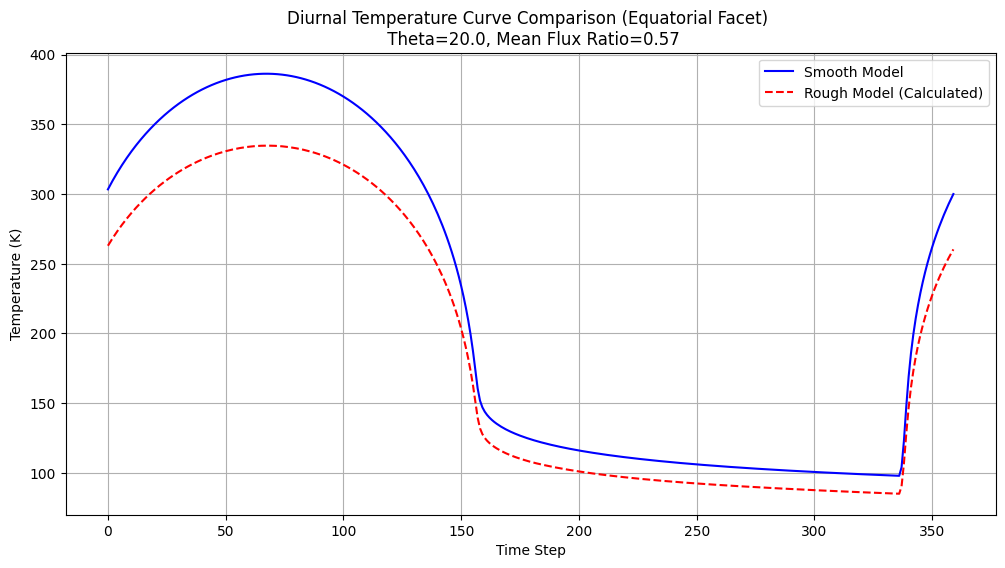

In [5]:
# Interpolate rough_factors to match temp_timesteps
x_lut = np.linspace(0, 1, lut_timesteps)
x_temp = np.linspace(0, 1, temp_timesteps)
factors_interp = np.interp(x_temp, x_lut, rough_factors)

# Calculate Effective Rough Temp
# T_rough^4 = T_smooth^4 * Factor
# T_rough = T_smooth * Factor^0.25

temps_rough_curve = temps_smooth_curve * (factors_interp ** 0.25)

plt.figure(figsize=(12, 6))
plt.plot(temps_smooth_curve, label='Smooth Model', color='blue')
plt.plot(temps_rough_curve, label='Rough Model (Calculated)', color='red', linestyle='--')

plt.title(f"Diurnal Temperature Curve Comparison (Equatorial Facet) \n Theta={theta_vals[theta_idx]}, Mean Flux Ratio={np.mean(rough_factors):.2f}")
plt.xlabel("Time Step")
plt.ylabel("Temperature (K)")
plt.legend()
plt.grid(True)
plt.show()

## 4. Normalization Strategy Answer

**Question:** *"Is this normalising correction applied for each timestep or over one full rotation?"*

**Answer:** The "Flux Ratio" plot above shows that the energy loss varies throughout the day. 
If we normalize **per timestep** (Instantaneous Normalization), we would force the Red curve (Rough) to land exactly on top of the Blue curve (Smooth) at every point (ignoring directional effects). This would effectively **erase** the thermal lag information provided by the roughness model.

If we normalize **over one full rotation** (Integrated Normalization):
1. We calculate the total daily energy `Sum(Rough)`. 
2. We calculate `Sum(Smooth)`.
3. We find a single scalar `Scalar = Sum(Smooth)/Sum(Rough)` (e.g. 1/0.57 = 1.75).
4. We multiply the Rough curve by `Scalar^0.25`. 

This preserves the *shape* of the rough curve (cooler noon, warmer night) but shifts it up so it emits the same total energy as the smooth model.

Let's visualize the "Rotation-Averaged Normalization" to see if it looks physically reasonable.

Scalar Normalization Factor (Energy): 1.7689


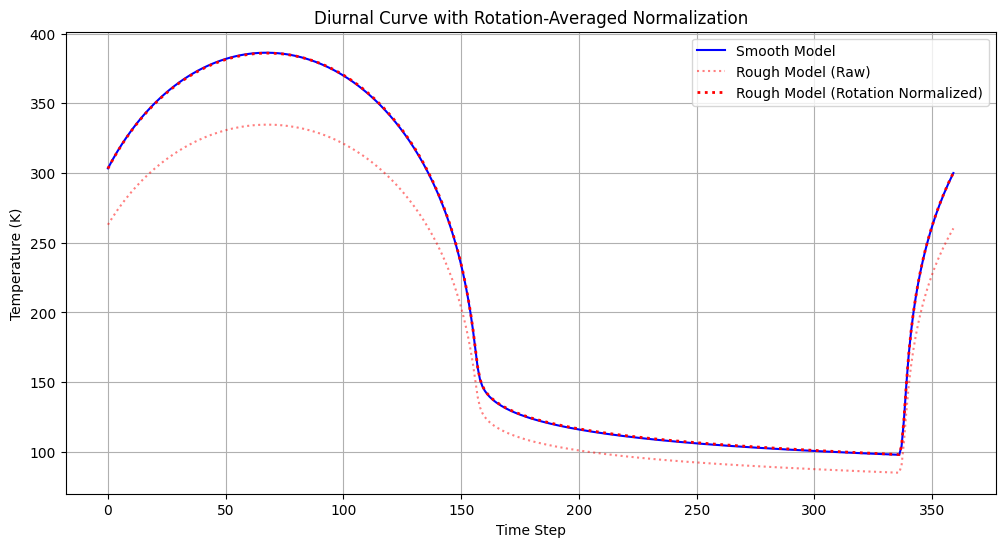

In [7]:
# Compute Rotation-Averaged Normalization Factor
total_energy_smooth = np.sum(temps_smooth_curve**4)
total_energy_rough = np.sum(temps_rough_curve**4)

scalar_factor = total_energy_smooth / total_energy_rough
print(f"Scalar Normalization Factor (Energy): {scalar_factor:.4f}")

# Apply Normalization
temps_rough_normalized = temps_rough_curve * (scalar_factor ** 0.25)

plt.figure(figsize=(12, 6))
plt.plot(temps_smooth_curve, label='Smooth Model', color='blue')
plt.plot(temps_rough_curve, label='Rough Model (Raw)', color='red', linestyle=':', alpha=0.5)
plt.plot(temps_rough_normalized, label='Rough Model (Rotation Normalized)', color='red', linestyle=':', linewidth=2)

plt.title("Diurnal Curve with Rotation-Averaged Normalization")
plt.xlabel("Time Step")
plt.ylabel("Temperature (K)")
plt.legend()
plt.grid(True)
plt.show()